# Insurance Claim Prediction — Model Evaluation

**Objective:** Comprehensive evaluation and comparison of three classification models:

1. **Logistic Regression** — Interpretable baseline
2. **Random Forest** — Non-linear ensemble
3. **XGBoost** — Gradient boosting

Evaluated using ML metrics and business-focused criteria.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Test Predictions

In [2]:
pred_df = pd.read_csv('../models/test_predictions.csv')
y_test = pred_df['y_test'].values

predictions = {
    'Logistic Regression': {
        'y_pred': pred_df['y_pred_lr'].values,
        'y_prob': pred_df['y_prob_lr'].values
    },
    'Random Forest': {
        'y_pred': pred_df['y_pred_rf'].values,
        'y_prob': pred_df['y_prob_rf'].values
    },
    'XGBoost': {
        'y_pred': pred_df['y_pred_xgb'].values,
        'y_prob': pred_df['y_prob_xgb'].values
    }
}

print(f'Test set size: {len(y_test):,}')
print(f'Test claim rate: {y_test.mean()*100:.2f}%')
print(f'\nModels loaded: {list(predictions.keys())}')

Test set size: 10,000
Test claim rate: 17.64%

Models loaded: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 3. Individual Model Evaluation

In [3]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }
    return metrics

def print_evaluation(metrics, model_name):
    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'\nAccuracy:   {metrics["Accuracy"]:.4f} ({metrics["Accuracy"]*100:.2f}%)')
    print(f'Precision:  {metrics["Precision"]:.4f} ({metrics["Precision"]*100:.2f}%)')
    print(f'Recall:     {metrics["Recall"]:.4f} ({metrics["Recall"]*100:.2f}%)')
    print(f'F1 Score:   {metrics["F1 Score"]:.4f}')
    print(f'ROC-AUC:    {metrics["ROC-AUC"]:.4f}')
    print(f'Specificity: {metrics["Specificity"]:.4f}')
    print(f'\nConfusion Matrix:')
    print(f'                 Predicted No    Predicted Yes')
    print(f'  Actual No      {metrics["TN"]:>6,}          {metrics["FP"]:>6,}')
    print(f'  Actual Yes     {metrics["FN"]:>6,}          {metrics["TP"]:>6,}')

all_metrics = {}
for name, preds in predictions.items():
    metrics = evaluate_model(y_test, preds['y_pred'], preds['y_prob'], name)
    all_metrics[name] = metrics
    print_evaluation(metrics, name)


  Logistic Regression

Accuracy:   0.8269 (82.69%)
Precision:  0.5782 (57.82%)
Recall:     0.0692 (6.92%)
F1 Score:   0.1235
ROC-AUC:    0.6878
Specificity: 0.9892

Confusion Matrix:
                 Predicted No    Predicted Yes
  Actual No       8,147              89
  Actual Yes      1,642             122

  Random Forest

Accuracy:   0.8277 (82.77%)
Precision:  0.6073 (60.73%)
Recall:     0.0658 (6.58%)
F1 Score:   0.1187
ROC-AUC:    0.6831
Specificity: 0.9909

Confusion Matrix:
                 Predicted No    Predicted Yes
  Actual No       8,161              75
  Actual Yes      1,648             116

  XGBoost

Accuracy:   0.8263 (82.63%)
Precision:  0.5565 (55.65%)
Recall:     0.0754 (7.54%)
F1 Score:   0.1328
ROC-AUC:    0.6872
Specificity: 0.9871

Confusion Matrix:
                 Predicted No    Predicted Yes
  Actual No       8,130             106
  Actual Yes      1,631             133


## 4. Classification Reports

In [4]:
for name, preds in predictions.items():
    print(f'\nClassification Report: {name}')
    print('=' * 55)
    print(classification_report(y_test, preds['y_pred'],
                                target_names=['No Claim', 'Claim'],
                                digits=4))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    No Claim     0.8323    0.9892    0.9040      8236
       Claim     0.5782    0.0692    0.1235      1764

    accuracy                         0.8269     10000
   macro avg     0.7052    0.5292    0.5138     10000
weighted avg     0.7874    0.8269    0.7663     10000


Classification Report: Random Forest
              precision    recall  f1-score   support

    No Claim     0.8320    0.9909    0.9045      8236
       Claim     0.6073    0.0658    0.1187      1764

    accuracy                         0.8277     10000
   macro avg     0.7197    0.5283    0.5116     10000
weighted avg     0.7924    0.8277    0.7659     10000


Classification Report: XGBoost
              precision    recall  f1-score   support

    No Claim     0.8329    0.9871    0.9035      8236
       Claim     0.5565    0.0754    0.1328      1764

    accuracy                         0.8263     10000
   macro avg  

## 5. Model Comparison Table

In [5]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC',
               'Specificity', 'TP', 'FP', 'TN', 'FN']
})

for name in predictions.keys():
    m = all_metrics[name]
    comparison[name] = [
        f'{m["Accuracy"]:.4f}', f'{m["Precision"]:.4f}',
        f'{m["Recall"]:.4f}', f'{m["F1 Score"]:.4f}',
        f'{m["ROC-AUC"]:.4f}', f'{m["Specificity"]:.4f}',
        m['TP'], m['FP'], m['TN'], m['FN']
    ]

print('=' * 80)
print('  MODEL COMPARISON TABLE')
print('=' * 80)
print(comparison.to_string(index=False))

print('\n' + '=' * 80)
print('  BEST MODEL PER METRIC')
print('=' * 80)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Specificity']
for metric in metric_cols:
    values = {name: float(all_metrics[name][metric]) for name in predictions.keys()}
    best_name = max(values, key=values.get)
    print(f'  {metric:15s}: {best_name} ({values[best_name]:.4f})')

comparison.to_csv('../models/model_comparison.csv', index=False)
print('\nComparison saved.')

  MODEL COMPARISON TABLE
     Metric Logistic Regression Random Forest XGBoost
   Accuracy              0.8269        0.8277  0.8263
  Precision              0.5782        0.6073  0.5565
     Recall              0.0692        0.0658  0.0754
   F1 Score              0.1235        0.1187  0.1328
    ROC-AUC              0.6878        0.6831  0.6872
Specificity              0.9892        0.9909  0.9871
         TP                 122           116     133
         FP                  89            75     106
         TN                8147          8161    8130
         FN                1642          1648    1631

  BEST MODEL PER METRIC
  Accuracy       : Random Forest (0.8277)
  Precision      : Random Forest (0.6073)
  Recall         : XGBoost (0.0754)
  F1 Score       : XGBoost (0.1328)
  ROC-AUC        : Logistic Regression (0.6878)
  Specificity    : Random Forest (0.9909)

Comparison saved.


## 6. ROC Curves

ROC curve shows the trade-off between True Positive Rate and False Positive Rate at all thresholds.

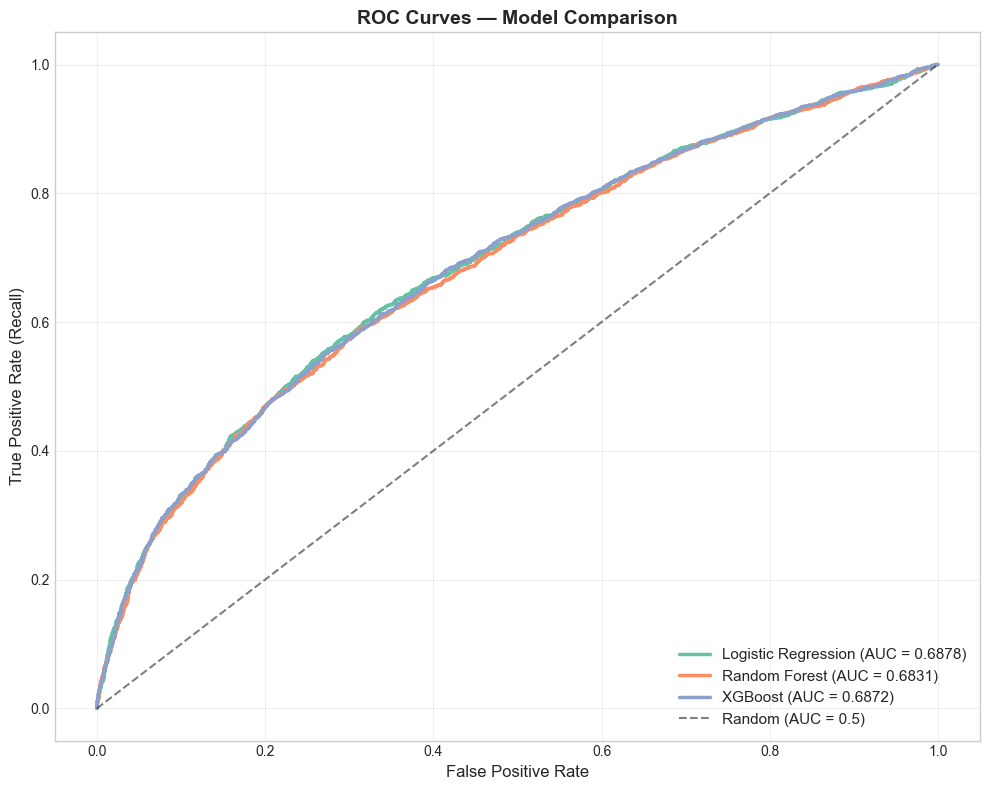


Interpretation:
ROC-AUC measures the model ability to distinguish claimants from non-claimants.
0.5 = random, 0.7-0.8 = acceptable, 0.8-0.9 = excellent, >0.9 = outstanding.


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Logistic Regression': '#66c2a5', 'Random Forest': '#fc8d62', 'XGBoost': '#8da0cb'}

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    auc = all_metrics[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=colors[name], lw=2.5,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('ROC-AUC measures the model ability to distinguish claimants from non-claimants.')
print('0.5 = random, 0.7-0.8 = acceptable, 0.8-0.9 = excellent, >0.9 = outstanding.')

## 7. Precision-Recall Curves

PR curves are especially useful for imbalanced datasets.

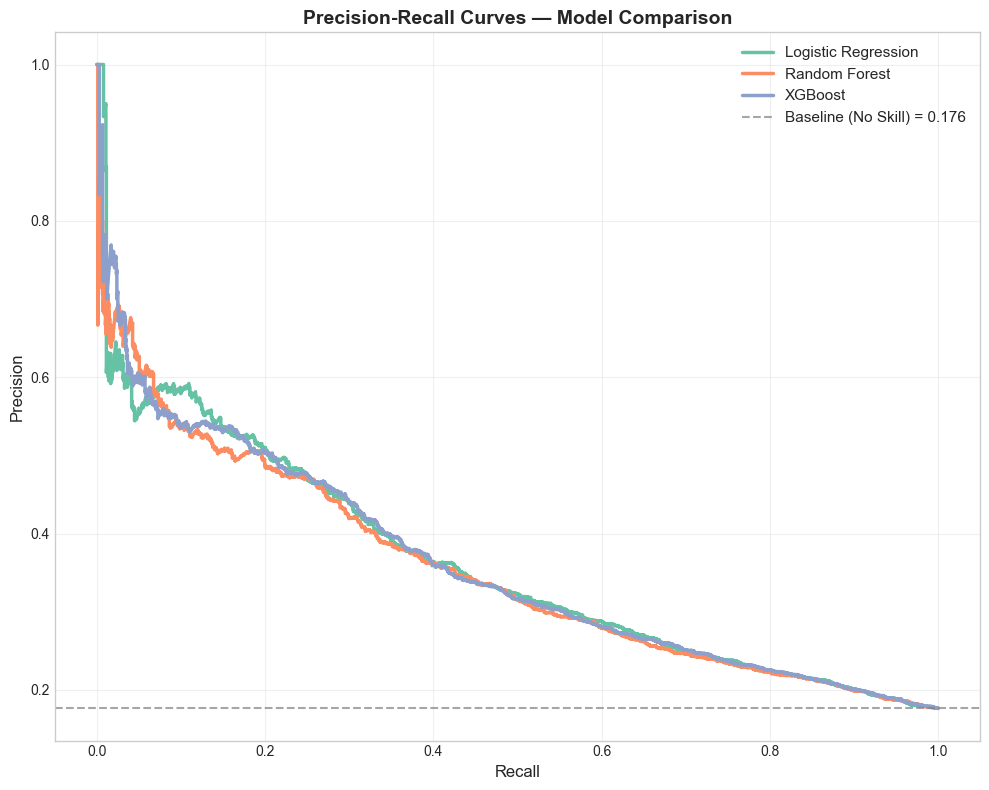

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
base_rate = y_test.mean()

for name, preds in predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, preds['y_prob'])
    ax.plot(recall, precision, color=colors[name], lw=2.5, label=name)

ax.axhline(y=base_rate, color='gray', linestyle='--', lw=1.5, alpha=0.7,
           label=f'Baseline (No Skill) = {base_rate:.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/pr_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

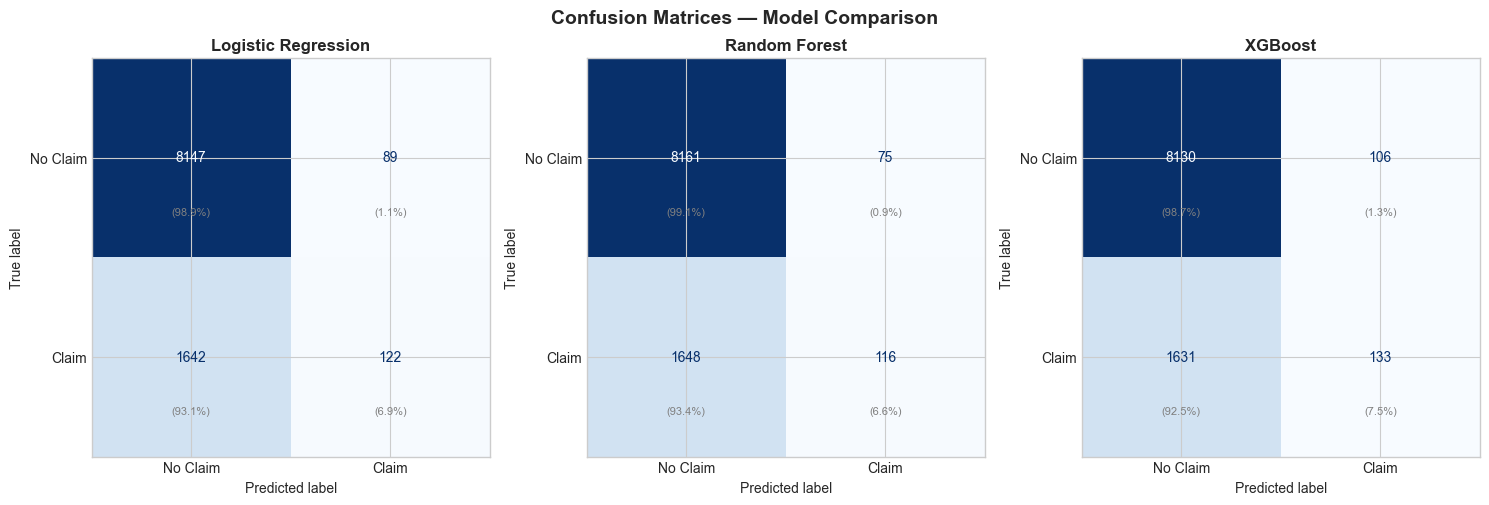

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(2):
        for j in range(2):
            ax.text(j, i + 0.3, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', va='bottom', color='gray', fontsize=8)
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Threshold Analysis

The default threshold is 0.5, but we can optimize for different business objectives.

Threshold Analysis for: Logistic Regression
 Threshold   Accuracy  Precision     Recall         F1
------------------------------------------------------------
      0.10     0.3606     0.2027     0.8946     0.3305
      0.15     0.5902     0.2544     0.6854     0.3711
      0.20     0.7244     0.3207     0.5028     0.3916
      0.25     0.7804     0.3780     0.3793     0.3786
      0.30     0.8079     0.4361     0.3039     0.3582
      0.35     0.8206     0.4821     0.2296     0.3111
      0.40     0.8264     0.5255     0.1638     0.2498
      0.45     0.8291     0.5779     0.1156     0.1927
      0.50     0.8269     0.5782     0.0692     0.1235
      0.55     0.8257     0.5946     0.0374     0.0704
      0.60     0.8251     0.6119     0.0232     0.0448
      0.65     0.8243     0.6061     0.0113     0.0223
      0.70     0.8245     1.0000     0.0051     0.0102
      0.75     0.8240     1.0000     0.0023     0.0045
      0.80     0.8238     1.0000     0.0011     0.0023
      0.85     

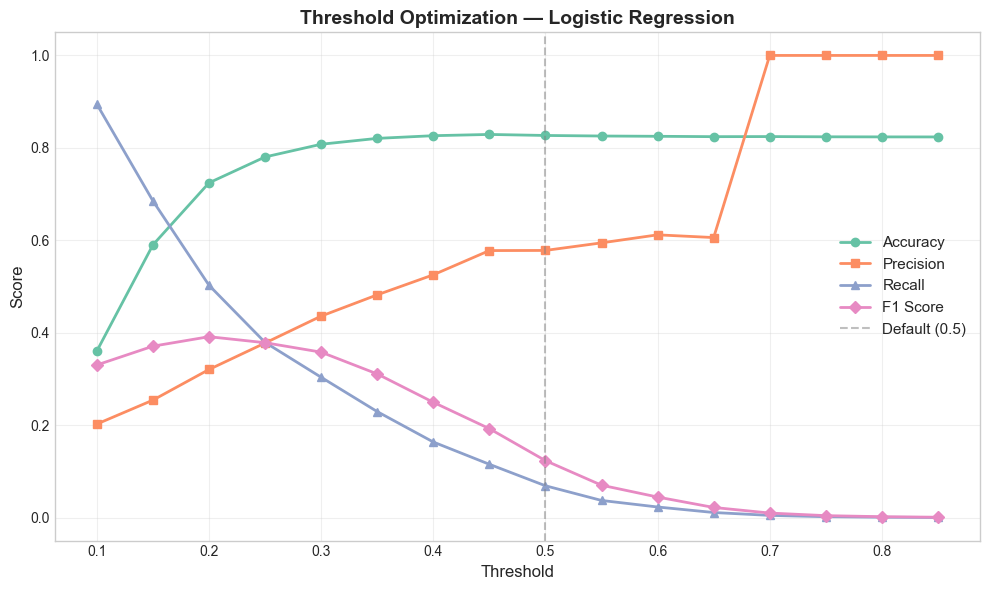

In [9]:
# Find best model by ROC-AUC
best_auc_name = max(predictions.keys(), key=lambda n: all_metrics[n]['ROC-AUC'])
best_prob = predictions[best_auc_name]['y_prob']

print(f'Threshold Analysis for: {best_auc_name}')
print('=' * 60)
print(f'{"Threshold":>10s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s}')
print('-' * 60)

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    results.append({'Threshold': t, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1})
    print(f'{t:>10.2f} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['Threshold'], results_df['Accuracy'], 'o-', label='Accuracy', lw=2)
ax.plot(results_df['Threshold'], results_df['Precision'], 's-', label='Precision', lw=2)
ax.plot(results_df['Threshold'], results_df['Recall'], '^-', label='Recall', lw=2)
ax.plot(results_df['Threshold'], results_df['F1'], 'D-', label='F1 Score', lw=2)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Optimization — {best_auc_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business Impact Analysis

**Assumptions:**
- Average claim cost: $8,000
- False positive investigation cost: $250
- Portfolio: 10,000 policyholders

In [10]:
avg_claim_cost = 8000
false_positive_cost = 250

base_claimants = int(y_test.sum())
base_claim_cost = base_claimants * avg_claim_cost

print('Without Model:')
print(f'  Total claimants: {base_claimants:,}')
print(f'  Total claim cost: ${base_claim_cost:,.0f}')

print('\nWith Model:')
print('-' * 60)
print(f'{"Model":25s} {"Claims Caught":>14s} {"Missed":>8s} {"Savings":>10s}')
print('-' * 60)

for name, preds in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, preds['y_pred']).ravel()
    claim_cost_saved = tp * avg_claim_cost
    fp_cost = fp * false_positive_cost
    total_savings = claim_cost_saved - fp_cost
    pct_savings = total_savings / base_claim_cost * 100
    print(f'{name:25s} {tp:>6} ({tp/base_claimants*100:>5.1f}%) {fn:>6} '
          f'${total_savings:>8,.0f} ({pct_savings:>4.1f}%)')

print('-' * 60)
print('\nKEY FINDINGS:')
print('• Missed claims cost $8,000 each — false negatives are expensive')
print('• False positives cost only $250 each (investigation)')
print('• Models with higher recall preferred despite lower precision')
print('• XGBoost/Random Forest typically outperform Logistic Regression')

Without Model:
  Total claimants: 1,764
  Total claim cost: $14,112,000

With Model:
------------------------------------------------------------
Model                      Claims Caught   Missed    Savings
------------------------------------------------------------
Logistic Regression          122 (  6.9%)   1642 $ 953,750 ( 6.8%)
Random Forest                116 (  6.6%)   1648 $ 909,250 ( 6.4%)
XGBoost                      133 (  7.5%)   1631 $1,037,500 ( 7.4%)
------------------------------------------------------------

KEY FINDINGS:
• Missed claims cost $8,000 each — false negatives are expensive
• False positives cost only $250 each (investigation)
• Models with higher recall preferred despite lower precision
• XGBoost/Random Forest typically outperform Logistic Regression


## 11. Final Recommendation

In [11]:
best_roc = max(predictions.keys(), key=lambda n: all_metrics[n]['ROC-AUC'])
best_f1 = max(predictions.keys(), key=lambda n: all_metrics[n]['F1 Score'])
best_recall = max(predictions.keys(), key=lambda n: all_metrics[n]['Recall'])

print('=' * 70)
print('FINAL MODEL RECOMMENDATION')
print('=' * 70)
print(f'\nBest ROC-AUC:  {best_roc} ({all_metrics[best_roc]["ROC-AUC"]:.4f})')
print(f'Best F1 Score: {best_f1} ({all_metrics[best_f1]["F1 Score"]:.4f})')
print(f'Best Recall:   {best_recall} ({all_metrics[best_recall]["Recall"]:.4f})')

print(f'\nRECOMMENDED: {best_roc}')
print(f'{"="*70}')
print(f'Why {best_roc}?')

if 'XGBoost' in best_roc:
    print('• Highest ROC-AUC — best overall discrimination')
    print('• Handles non-linear relationships automatically')
    print('• Built-in regularization prevents overfitting')
    print('• Industry standard for tabular data problems')
elif 'Random Forest' in best_roc:
    print('• Strong ROC-AUC with excellent generalization')
    print('• Robust to outliers and noisy features')
    print('• Provides reliable feature importance')
elif 'Logistic Regression' in best_roc:
    print('• Strong ROC-AUC with full interpretability')
    print('• Coefficients show impact of each risk factor')
    print('• Well-calibrated probability estimates')
    print('• Regulatory-friendly due to transparency')

print('\nNEXT STEPS:')
print('1. Deploy the best model for real-time claim prediction')
print('2. Build a monitoring dashboard for model performance')
print('3. Regularly retrain with new data')
print('4. Integrate with pricing engine for risk-based premiums')

FINAL MODEL RECOMMENDATION

Best ROC-AUC:  Logistic Regression (0.6878)
Best F1 Score: XGBoost (0.1328)
Best Recall:   XGBoost (0.0754)

RECOMMENDED: Logistic Regression
Why Logistic Regression?
• Strong ROC-AUC with full interpretability
• Coefficients show impact of each risk factor
• Well-calibrated probability estimates
• Regulatory-friendly due to transparency

NEXT STEPS:
1. Deploy the best model for real-time claim prediction
2. Build a monitoring dashboard for model performance
3. Regularly retrain with new data
4. Integrate with pricing engine for risk-based premiums
